In [ ]:
%pip install pycocotools pillow scikit-image ipywidgets ace-tools matplotlib scikit-learn pandas torch torchvision transformers timm datasets tensorboard

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK']='1'
os.environ["HF_TOKEN"] = "hf_XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX"

In [2]:
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import RandomSampler  # ← ADD THIS IMPORT
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms, models
from PIL import Image
from pycocotools.coco import COCO
from collections import defaultdict
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import linear_sum_assignment
from torch.utils.data import RandomSampler
import time
from torch.profiler import profile, record_function, ProfilerActivity
import warnings
from torch.optim.lr_scheduler import OneCycleLR
warnings.filterwarnings('ignore')

# Домашнее задание 2: Минимальный детектор на DETR/Deformable-DETR

### Цель

Освоить трансформерные архитектуры для объектной детекции, научиться настраивать и обучать DETR/Deformable-DETR на подмножестве COCO, анализировать loss и ошибки.

### Задание

1. Подготовить датасет: взять COCO-subset (минимум 10 классов).

In [3]:
dataDir = '.'
dataType = 'val2017'
annFile = '{}/annotations/instances_{}.json'.format(dataDir, dataType)
coco = COCO(annFile)

# Получаем все категории
catIds = coco.getCatIds()
cats = coco.loadCats(catIds)
nms = [cat['name'] for cat in cats]

# Считаем количество аннотаций (объектов) для каждой категории
cat_counts = {}
for catId in catIds:
    # Получаем все аннотации для текущей категории
    annIds = coco.getAnnIds(catIds=[catId])
    cat_counts[catId] = len(annIds)

# Сортируем категории по количеству объектов (от самых редких к самым частым)
sorted_cats = sorted(zip(cat_counts.values(), catIds), key=lambda x: x[0])

print("Топ-10 самых частых классов в val2017:")
print("-" * 40)
for count, catId in sorted_cats[-10:]:
    cat_name = coco.loadCats([catId])[0]['name']
    print(f"{cat_name:20} : {count:6} объектов")

loading annotations into memory...
Done (t=0.24s)
creating index...
index created!
Топ-10 самых частых классов в val2017:
----------------------------------------
handbag              :    540 объектов
bowl                 :    626 объектов
traffic light        :    637 объектов
dining table         :    697 объектов
cup                  :    899 объектов
bottle               :   1025 объектов
book                 :   1161 объектов
chair                :   1791 объектов
car                  :   1932 объектов
person               :  11004 объектов


In [4]:
def stratified_split_coco(val_ann_file, output_dir='.', train_ratio=0.8):
    
    with open(val_ann_file, 'r') as f:
        coco_data = json.load(f)
    
    img_to_classes = defaultdict(set)
    for ann in coco_data['annotations']:
        img_to_classes[ann['image_id']].add(ann['category_id'])
    
    all_img_ids = list(img_to_classes.keys())
    
    img_groups = defaultdict(list)
    for img_id in all_img_ids:
        num_classes = len(img_to_classes[img_id])
        img_groups[num_classes].append(img_id)
    
    train_img_ids = set()
    test_img_ids = set()
    
    np.random.seed(42)
    for num_classes, img_ids in img_groups.items():
        np.random.shuffle(img_ids)
        split_idx = int(len(img_ids) * train_ratio)
        train_img_ids.update(img_ids[:split_idx])
        test_img_ids.update(img_ids[split_idx:])
    
    print(f"Всего: {len(all_img_ids)} изображений")
    print(f"Train: {len(train_img_ids)} ({len(train_img_ids)/len(all_img_ids)*100:.1f}%)")
    print(f"Test: {len(test_img_ids)} ({len(test_img_ids)/len(all_img_ids)*100:.1f}%)")
    
    # Сохраняем (как в первом способе)
    def save_split(img_ids, name):
        filtered = {
            'info': coco_data.get('info', {}),
            'licenses': coco_data.get('licenses', []),
            'categories': coco_data['categories'],
            'images': [img for img in coco_data['images'] if img['id'] in img_ids],
            'annotations': [ann for ann in coco_data['annotations'] if ann['image_id'] in img_ids]
        }
        
        os.makedirs(output_dir, exist_ok=True)
        with open(os.path.join(output_dir, f'instances_{name}.json'), 'w') as f:
            json.dump(filtered, f)
    
    save_split(train_img_ids, 'train')
    save_split(test_img_ids, 'test')

In [5]:
stratified_split_coco('annotations/instances_val2017.json')

Всего: 4952 изображений
Train: 3955 (79.9%)
Test: 997 (20.1%)


In [ ]:
class Config:
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    data_path = '.'
    batch_size = 2
    epochs = 4
    lr = 5e-4
    weight_decay = 5e-2
    lr_drop = 8
    n_queries = 50
    d_model = 256
    nhead = 8
    num_encoder_layers = 6
    num_decoder_layers = 6
    num_classes = 10
    log_dir = './logs'
    checkpoint_dir = './checkpoints'
    trace_dir = './traces'
    num_workers = 0
    train_samples_per_epoch = 400
    val_samples_per_epoch = 100
    dropout = 0.1
    
config = Config()

os.makedirs(config.log_dir, exist_ok=True)
os.makedirs(config.checkpoint_dir, exist_ok=True)
os.makedirs(config.trace_dir, exist_ok=True)

In [ ]:
class COCOSubset(Dataset):
    def __init__(self, img_dir, ann_file, num_classes=10, split='train'):
        self.coco = COCO(ann_file)
        self.img_dir = img_dir
        self.split = split
        
        # Filter to top num_classes
        class_counts = defaultdict(int)
        for ann in self.coco.anns.values():
            class_counts[ann['category_id']] += 1
        
        top_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)[1:num_classes+1]
        self.class_ids = {cat_id: idx for idx, (cat_id, _) in enumerate(top_classes)}
        self.id_to_class = {idx: cat_id for cat_id, idx in self.class_ids.items()}
        self.class_names = {
            self.class_ids[cat_id]: self.coco.cats[cat_id]['name']
            for cat_id in self.class_ids.keys()
        }
        self.num_classes = len(self.class_ids)
        
        # Get valid images
        self.image_ids = []
        for img_id in self.coco.getImgIds():
            ann_ids = self.coco.getAnnIds(imgIds=[img_id])
            anns = self.coco.loadAnns(ann_ids)
            if any(ann['category_id'] in self.class_ids for ann in anns):
                self.image_ids.append(img_id)
        
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        self.all_labels = []
        for img_id in self.image_ids:
            ann_ids = self.coco.getAnnIds(imgIds=[img_id])
            anns = self.coco.loadAnns(ann_ids)
            for ann in anns:
                if ann['category_id'] in self.class_ids:
                    self.all_labels.append(self.class_ids[ann['category_id']])
        
        print(f"Total annotations collected: {len(self.all_labels)}")
        
        print(f"[{split}] Classes: {self.num_classes}, Images: {len(self.image_ids)}")
        if len(self.image_ids) > 0:
            print(f"Sample image path: {os.path.join(self.img_dir, self.coco.loadImgs(self.image_ids[0])[0]['file_name'])}")
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        
        if not os.path.exists(img_path):
            print(f"Warning: Image not found: {img_path}")
            return self.__getitem__((idx + 1) % len(self.image_ids))
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            return self.__getitem__((idx + 1) % len(self.image_ids))
        
        orig_size = torch.tensor([image.height, image.width])
        ann_ids = self.coco.getAnnIds(imgIds=[img_id])
        anns = self.coco.loadAnns(ann_ids)
        
        boxes = []
        labels = []
        for ann in anns:
            if ann['category_id'] not in self.class_ids:
                continue
            
            x, y, w, h = ann['bbox']
            if w <= 0 or h <= 0:
                continue
            
            x1 = max(0, x) / img_info['width']
            y1 = max(0, y) / img_info['height']
            x2 = min(x + w, img_info['width']) / img_info['width']
            y2 = min(y + h, img_info['height']) / img_info['height']
            
            x1 = max(0.0, min(1.0, x1))
            y1 = max(0.0, min(1.0, y1))
            x2 = max(0.0, min(1.0, x2))
            y2 = max(0.0, min(1.0, y2))
            
            if x2 > x1 and y2 > y1:
                boxes.append([x1, y1, x2, y2])
                labels.append(self.class_ids[ann['category_id']])
        
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            
            # Ensure boxes are in xyxy format and clamped
            boxes = torch.clamp(boxes, 0.0, 1.0)
        
        image_tensor = self.transform(image)

        return {
            'image': image_tensor,
            'boxes': boxes,  # Already in xyxy format
            'labels': labels,
            'orig_size': orig_size,
            'image_id': img_id
        }

    def get_class_weights(self):
        """Получить веса для каждого класса"""
        from collections import Counter
        
        # Подсчет количества объектов каждого класса
        class_counts = Counter(self.all_labels)
        print(f"Class distribution: {class_counts}")
        
        # Вес = 1 / (частота класса)
        total = len(self.all_labels)
        class_weights = {}
        for class_id, count in class_counts.items():
            class_weights[class_id] = total / count
        
        return class_weights, class_counts

def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    
    max_h = max(item['image'].shape[1] for item in batch)
    max_w = max(item['image'].shape[2] for item in batch)
    
    padded_images = []
    for item in batch:
        img = item['image']
        c, h, w = img.shape
        padded = torch.zeros(c, max_h, max_w)
        padded[:, :h, :w] = img
        padded_images.append(padded)
    
    images = torch.stack(padded_images)
    boxes = [item['boxes'] for item in batch]
    labels = [item['labels'] for item in batch]
    orig_sizes = torch.stack([item['orig_size'] for item in batch])
    image_ids = [item['image_id'] for item in batch]
    
    return {
        'images': images,
        'boxes': boxes,
        'labels': labels,
        'orig_sizes': orig_sizes,
        'image_ids': image_ids
    }

2. Запустить fine-tuning DETR или Deformable-DETR на этом наборе.

In [ ]:
class Backbone(nn.Module):
    def __init__(self, name='resnet50', pretrained=True):
        super().__init__()
        if name == 'resnet50':
            backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None)
            self.num_channels = 2048
        else:
            backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
            self.num_channels = 512
        
        self.body = nn.Sequential(*list(backbone.children())[:-2])
        self.proj = nn.Conv2d(self.num_channels, config.d_model, kernel_size=1)
        
    def forward(self, x):
        x = self.body(x)
        x = self.proj(x)
        mask = torch.zeros(x.shape[0], x.shape[2], x.shape[3], dtype=torch.bool, device=x.device)
        return x, mask

class PositionalEncoding(nn.Module):
    def __init__(self, d_model=256, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        return self.pe[:x.size(1)]

class TransformerEncoder(nn.Module):
    def __init__(self, d_model=256, nhead=8, num_layers=6, dim_feedforward=2048, dropout=config.dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
            for _ in range(num_layers)
        ])
    
    def forward(self, src, mask=None):
        x = src
        for layer in self.layers:
            x = layer(x, src_key_padding_mask=mask)
        return x

class TransformerDecoder(nn.Module):
    def __init__(self, d_model=256, nhead=8, num_layers=6, dim_feedforward=2048, dropout=config.dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.TransformerDecoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
            for _ in range(num_layers)
        ])
    
    def forward(self, tgt, memory, tgt_mask=None, memory_mask=None, tgt_key_padding_mask=None, memory_key_padding_mask=None):
        x = tgt
        for layer in self.layers:
            x = layer(x, memory, tgt_mask, memory_mask, tgt_key_padding_mask, memory_key_padding_mask)
        return x

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super().__init__()
        layers = []
        for i in range(num_layers):
            dim_in = input_dim if i == 0 else hidden_dim
            dim_out = output_dim if i == num_layers - 1 else hidden_dim
            layers.append(nn.Linear(dim_in, dim_out))
            if i < num_layers - 1:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

class DETRHeads(nn.Module):
    def __init__(self, d_model=256, num_classes=91, n_queries=100):
        super().__init__()
        self.class_head = nn.Linear(d_model, num_classes + 1)
        self.bbox_head = MLP(d_model, d_model, 4, 3)
    
    def forward(self, x):
        logits = self.class_head(x)
        boxes_cxcywh = self.bbox_head(x).sigmoid()
        # Convert to xyxy
        boxes_xyxy = torch.cat([
            boxes_cxcywh[..., :2] - 0.5 * boxes_cxcywh[..., 2:],
            boxes_cxcywh[..., :2] + 0.5 * boxes_cxcywh[..., 2:]
        ], dim=-1)
        # Clamp to [0, 1]
        boxes_xyxy = torch.clamp(boxes_xyxy, 0.0, 1.0)
        return logits, boxes_xyxy

class DETR(nn.Module):
    def __init__(self, num_classes=91, n_queries=100, d_model=256):
        super().__init__()
        self.backbone = Backbone('resnet50')
        self.pos_encoder = PositionalEncoding(d_model)
        self.query_embed = nn.Embedding(n_queries, d_model)
        self.encoder = TransformerEncoder(d_model, config.nhead, config.num_encoder_layers)
        self.decoder = TransformerDecoder(d_model, config.nhead, config.num_decoder_layers)
        self.heads = DETRHeads(d_model, num_classes, n_queries)
        
    def forward(self, images):
        features, mask = self.backbone(images)
        bs, c, h, w = features.shape
        
        src = features.flatten(2).permute(0, 2, 1)
        pos = self.pos_encoder(src).unsqueeze(0).expand(bs, -1, -1)
        mask_flat = mask.reshape(bs, -1)
        
        memory = self.encoder(src + pos, mask_flat)
        
        queries = self.query_embed.weight.unsqueeze(0).expand(bs, -1, -1)
        tgt = queries
        hs = self.decoder(tgt, memory, memory_key_padding_mask=mask_flat)
        
        logits, boxes = self.heads(hs)
        
        return {'logits': logits, 'boxes': boxes}

In [ ]:
def generalized_box_iou(boxes1, boxes2):
    
    boxes1_expanded = boxes1.unsqueeze(1)
    boxes2_expanded = boxes2.unsqueeze(0)
    
    inter_x1 = torch.max(boxes1_expanded[..., 0], boxes2_expanded[..., 0])
    inter_y1 = torch.max(boxes1_expanded[..., 1], boxes2_expanded[..., 1])
    inter_x2 = torch.min(boxes1_expanded[..., 2], boxes2_expanded[..., 2])
    inter_y2 = torch.min(boxes1_expanded[..., 3], boxes2_expanded[..., 3])
    
    inter_w = (inter_x2 - inter_x1).clamp(min=0)
    inter_h = (inter_y2 - inter_y1).clamp(min=0)
    inter_area = inter_w * inter_h
    
    area1 = (boxes1_expanded[..., 2] - boxes1_expanded[..., 0]) * \
            (boxes1_expanded[..., 3] - boxes1_expanded[..., 1])
    area2 = (boxes2_expanded[..., 2] - boxes2_expanded[..., 0]) * \
            (boxes2_expanded[..., 3] - boxes2_expanded[..., 1])
    
    union = area1 + area2 - inter_area + 1e-7
    
    hull_x1 = torch.min(boxes1_expanded[..., 0], boxes2_expanded[..., 0])
    hull_y1 = torch.min(boxes1_expanded[..., 1], boxes2_expanded[..., 1])
    hull_x2 = torch.max(boxes1_expanded[..., 2], boxes2_expanded[..., 2])
    hull_y2 = torch.max(boxes1_expanded[..., 3], boxes2_expanded[..., 3])
    
    hull_w = hull_x2 - hull_x1
    hull_h = hull_y2 - hull_y1
    hull_area = hull_w * hull_h + 1e-7
    
    iou = inter_area / union
    giou = iou - (hull_area - union) / hull_area
    
    return giou

def compute_loss(pred_logits, pred_boxes, target_labels, target_boxes, num_classes):
    bs, n_queries = pred_logits.shape[:2]
    device = pred_logits.device
    
    total_class_loss = torch.tensor(0.0, device=device)
    total_bbox_loss = torch.tensor(0.0, device=device)
    total_giou_loss = torch.tensor(0.0, device=device)
    num_valid = 0
    
    for i in range(bs):
        tgt_labels = target_labels[i]
        tgt_boxes = target_boxes[i]
        
        if len(tgt_labels) == 0:
            loss_cls = F.cross_entropy(
                pred_logits[i], 
                torch.full((n_queries,), num_classes, device=device, dtype=torch.long)
            )
            total_class_loss += loss_cls
            num_valid += 1
            continue
        
        tgt_labels = tgt_labels.to(device)
        tgt_boxes = tgt_boxes.to(device)
        
        out_prob = pred_logits[i].softmax(-1)
        out_bbox = pred_boxes[i]
        
        cost_class = -out_prob[:, tgt_labels]
        cost_bbox = torch.cdist(out_bbox, tgt_boxes, p=1)
        cost_giou = 1 - generalized_box_iou(out_bbox, tgt_boxes)
        
        C = cost_class + 5 * cost_bbox + 2 * cost_giou
        
        C_np = C.detach().cpu().numpy()
        indices = linear_sum_assignment(C_np.T)
        
        pred_idx = torch.as_tensor(indices[1], device=device)
        gt_idx = torch.as_tensor(indices[0], device=device)
        
        loss_cls = F.cross_entropy(out_prob[pred_idx], tgt_labels[gt_idx])
        loss_bbox = F.l1_loss(out_bbox[pred_idx], tgt_boxes[gt_idx])
        
        giou_matched = generalized_box_iou(out_bbox[pred_idx], tgt_boxes[gt_idx])
        loss_giou = (1 - giou_matched.diag()).mean()
        
        total_class_loss += loss_cls
        total_bbox_loss += loss_bbox
        total_giou_loss += loss_giou
        num_valid += 1
    
    if num_valid > 0:
        return total_class_loss / num_valid, total_bbox_loss / num_valid, total_giou_loss / num_valid
    else:
        return torch.tensor(0.0, device=device), torch.tensor(0.0, device=device), torch.tensor(0.0, device=device)
    
def plot_loss_curves(log_dir, save_dir='./analysis'):
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"\n📈 Generating loss curves...")
    
    try:
        from tensorboard.backend.event_processing import event_accumulator
        
        ea = event_accumulator.EventAccumulator(log_dir)
        ea.Reload()
        
        # Extract metrics
        train_loss = [s.value for s in ea.Scalars('Train/Loss')]
        train_class = [s.value for s in ea.Scalars('Train/ClassLoss')]
        train_bbox = [s.value for s in ea.Scalars('Train/BBoxLoss')]
        train_giou = [s.value for s in ea.Scalars('Train/GIoULoss')]
        
        # Create plots
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        axes[0, 0].plot(train_loss, label='Train Loss', color='blue')
        axes[0, 0].set_title('Total Loss', fontsize=14)
        axes[0, 0].set_xlabel('Step')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].plot(train_class, label='Class Loss', color='red')
        axes[0, 1].set_title('Classification Loss', fontsize=14)
        axes[0, 1].set_xlabel('Step')
        axes[0, 1].set_ylabel('Loss')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        axes[1, 0].plot(train_bbox, label='BBox Loss', color='green')
        axes[1, 0].set_title('Bounding Box Regression Loss', fontsize=14)
        axes[1, 0].set_xlabel('Step')
        axes[1, 0].set_ylabel('Loss')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        axes[1, 1].plot(train_giou, label='GIoU Loss', color='orange')
        axes[1, 1].set_title('GIoU Loss', fontsize=14)
        axes[1, 1].set_xlabel('Step')
        axes[1, 1].set_ylabel('Loss')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.suptitle('Training Loss Curves', fontsize=16)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'loss_curves.png'), dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"✅ Loss curves saved to {save_dir}/loss_curves.png")
        
    except Exception as e:
        print(f"⚠️ Could not plot loss curves: {e}")
        print("   Make sure training has completed and logs exist")

In [ ]:
def train_epoch(model, dataloader, optimizer, scheduler, writer, epoch, num_classes):
    model.train()
    total_loss = torch.tensor(0.0, device=config.device)
    total_class_loss = torch.tensor(0.0, device=config.device)
    total_bbox_loss = torch.tensor(0.0, device=config.device)
    total_giou_loss = torch.tensor(0.0, device=config.device)
    
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch}")
    
    for batch_idx, batch in enumerate(progress_bar):
        if batch is None:
            continue
            
        images = batch['images'].to(config.device)
        boxes = batch['boxes']
        labels = batch['labels']
        
        optimizer.zero_grad()
        
        outputs = model(images)
        
        class_loss, bbox_loss, giou_loss = compute_loss(
            outputs['logits'], outputs['boxes'],
            labels, boxes, num_classes
        )
        
        loss = class_loss + bbox_loss + giou_loss
        
        # ========== ПРОВЕРКА НА ВЗРЫВ LOSS ==========
        loss_value = loss.item()
        
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"\n⚠️ WARNING: NaN/Inf loss detected at batch {batch_idx}")
            print(f"   Skipping this batch and reducing learning rate...")
            # Снижаем learning rate
            for param_group in optimizer.param_groups:
                param_group['lr'] *= 0.5
            # Пропускаем этот батч
            continue
        
        if loss_value > 10.0:
            print(f"\n⚠️ WARNING: Loss exploded: {loss_value:.2f} at batch {batch_idx}")
            print(f"   Class loss: {class_loss.item():.2f}, BBox: {bbox_loss.item():.2f}, GIoU: {giou_loss.item():.2f}")
            print(f"   Reducing learning rate and skipping backward pass...")
            
            # Снижаем learning rate
            for param_group in optimizer.param_groups:
                param_group['lr'] *= 0.5
            print(f"   New LR: {optimizer.param_groups[0]['lr']:.6f}")
            
            # Пропускаем backward для этого батча
            continue
        
        # Нормальное обучение
        loss.backward()
        
        grad_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                grad_norm += p.grad.norm().item() ** 2
        grad_norm = grad_norm ** 0.5
        
        if grad_norm > 10.0:
            print(f"\n⚠️ WARNING: Gradient explosion detected: {grad_norm:.2f}")
            print(f"   Clipping gradients more aggressively...")
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        else:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        
        optimizer.step()
        
        # Нормальное логирование
        total_loss += loss.detach()
        total_class_loss += class_loss.detach()
        total_bbox_loss += bbox_loss.detach()
        total_giou_loss += giou_loss.detach()
        
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'cls': f'{class_loss.item():.4f}',
            'bbox': f'{bbox_loss.item():.4f}'
        })
        
        if batch_idx % 10 == 0:
            step = epoch * len(dataloader) + batch_idx
            writer.add_scalar('Train/Loss', loss.item(), step)
            writer.add_scalar('Train/ClassLoss', class_loss.item(), step)
            writer.add_scalar('Train/BBoxLoss', bbox_loss.item(), step)
            writer.add_scalar('Train/GIoULoss', giou_loss.item(), step)
            writer.add_scalar('Train/GradientNorm', grad_norm, step)
            writer.add_scalar('Train/LearningRate', optimizer.param_groups[0]['lr'], step)
    
    if scheduler:
        scheduler.step()
    
    num_batches = max(len(dataloader), 1)
    avg_loss = total_loss.item() / num_batches
    avg_class_loss = total_class_loss.item() / num_batches
    avg_bbox_loss = total_bbox_loss.item() / num_batches
    avg_giou_loss = total_giou_loss.item() / num_batches
    
    writer.add_scalar('Epoch/TrainLoss', avg_loss, epoch)
    writer.add_scalar('Epoch/TrainClassLoss', avg_class_loss, epoch)
    writer.add_scalar('Epoch/TrainBBoxLoss', avg_bbox_loss, epoch)
    writer.add_scalar('Epoch/TrainGIoULoss', avg_giou_loss, epoch)
    
    return avg_loss, avg_class_loss, avg_bbox_loss, avg_giou_loss

def validate(model, dataloader, writer, epoch, num_classes):
    model.eval()
    total_loss = 0.0
    num_batches = 0
    
    with torch.no_grad():
        for _, batch in enumerate(tqdm(dataloader, desc="Validation")):
            if batch is None:
                continue
            
            images = batch['images'].to(config.device)
            boxes = batch['boxes']
            labels = batch['labels']
            
            outputs = model(images)
            
            class_loss, bbox_loss, giou_loss = compute_loss(
                outputs['logits'], outputs['boxes'],
                labels, boxes, num_classes
            )
            
            loss = class_loss + bbox_loss + giou_loss
            loss_val = loss.item() if hasattr(loss, 'item') else loss
            total_loss += loss_val
            num_batches += 1
    
    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    
    if writer and epoch is not None:
        writer.add_scalar('Epoch/ValLoss', avg_loss, epoch)
    
    return avg_loss

In [ ]:
def run_profiler(model, dataloader, device, trace_dir):
    """Run profiler and save trace"""
    print("\n📊 Running profiler...")
    
    # Create a small batch for profiling
    batch = None
    for b in dataloader:
        if b is not None:
            batch = b
            break
    
    if batch is None:
        print("⚠️ No data for profiling")
        return
    
    images = batch['images'][:2].to(device)  # Use 2 images for profiling
    
    def trace_handler(p):
        trace_path = os.path.join(trace_dir, f'trace_{int(time.time())}.json')
        p.export_chrome_trace(trace_path)
        print(f"✅ Trace saved to {trace_path}")
    
    # Choose activities based on device
    if device.type == 'cuda':
        activities = [ProfilerActivity.CPU, ProfilerActivity.CUDA]
    elif device.type == 'mps':
        # MPS doesn't have dedicated profiler activity, use CPU only
        activities = [ProfilerActivity.CPU]
        print("   Note: MPS profiling limited to CPU operations")
    else:
        activities = [ProfilerActivity.CPU]
    
    try:
        with profile(
            activities=activities,
            schedule=torch.profiler.schedule(wait=1, warmup=1, active=3, repeat=1),
            on_trace_ready=trace_handler,
            record_shapes=True,
            profile_memory=True if device.type == 'cuda' else False
        ) as prof:
            for step in range(5):
                with record_function("forward_pass"):
                    outputs = model(images)
                    loss = outputs['logits'].sum() + outputs['boxes'].sum()
                with record_function("backward_pass"):
                    loss.backward()
                prof.step()
        
        print("✅ Profiling complete")
    except Exception as e:
        print(f"⚠️ Profiler failed: {e}")
        print("   Continuing without profiler trace...")

def compute_map_and_metrics(model, dataloader, device, num_classes, class_names):
    """Compute mAP, mAP50, and other metrics"""
    model.eval()
    
    all_predictions = []
    all_targets = []
    
    print("\n📊 Computing mAP metrics...")
    
    with torch.no_grad():
        for _, batch in enumerate(tqdm(dataloader, desc="Computing mAP")):
            if batch is None:
                continue
            
            images = batch['images'].to(device)
            orig_sizes = batch['orig_sizes']
            image_ids = batch['image_ids']
            target_boxes = batch['boxes']
            target_labels = batch['labels']
            
            outputs = model(images)
            logits = outputs['logits']  # [B, Q, C+1]
            boxes = outputs['boxes']    # [B, Q, 4]
            
            for i in range(len(images)):
                scores = F.softmax(logits[i], dim=-1)[:, :-1].max(dim=-1)
                keep = scores.values > 0.5
                
                if keep.any():
                    pred_scores = scores.values[keep].cpu()
                    pred_labels = scores.indices[keep].cpu()
                    pred_boxes = boxes[i][keep].cpu()
                    
                    # Convert to COCO format [x, y, width, height]
                    pred_boxes_xyxy = pred_boxes  # Already in xyxy
                    w = pred_boxes_xyxy[:, 2] - pred_boxes_xyxy[:, 0]
                    h = pred_boxes_xyxy[:, 3] - pred_boxes_xyxy[:, 1]
                    coco_boxes = torch.stack([
                        pred_boxes_xyxy[:, 0],  # x
                        pred_boxes_xyxy[:, 1],  # y
                        w, h
                    ], dim=1)
                    
                    for score, label, bbox in zip(pred_scores, pred_labels, coco_boxes):
                        all_predictions.append({
                            'image_id': image_ids[i],
                            'category_id': int(label) + 1,  # COCO classes start at 1
                            'bbox': bbox.tolist(),
                            'score': float(score)
                        })
                
                # Store targets
                for label, bbox in zip(target_labels[i], target_boxes[i]):
                    if len(bbox) == 4:
                        w = bbox[2] - bbox[0]
                        h = bbox[3] - bbox[1]
                        all_targets.append({
                            'image_id': image_ids[i],
                            'category_id': int(label) + 1,
                            'bbox': [float(bbox[0]), float(bbox[1]), float(w), float(h)],
                            'iscrowd': 0
                        })
    
    # Calculate simple metrics
    if len(all_predictions) > 0:
        # Count predictions vs ground truth
        pred_by_class = defaultdict(int)
        for p in all_predictions:
            pred_by_class[p['category_id']] += 1
        
        gt_by_class = defaultdict(int)
        for t in all_targets:
            gt_by_class[t['category_id']] += 1
        
        print("📈 Per-class statistics:")
        print(f"{'Class':<15} {'GT Count':<10} {'Pred Count':<12} {'Precision':<10}")
        print("-" * 50)
        
        for class_id in range(1, num_classes + 1):
            gt_count = gt_by_class.get(class_id, 0)
            pred_count = pred_by_class.get(class_id, 0)
            precision = pred_count / gt_count if gt_count > 0 else 0
            class_name = class_names.get(class_id - 1, f"Class_{class_id}")
            print(f"{class_name:<15} {gt_count:<10} {pred_count:<12} {precision:<10.3f}")
    
    # For full COCO evaluation, you would need the actual COCO ground truth file
    # Return placeholder metrics
    metrics = {
        'mAP': 0.0,  # Would need COCOeval with ground truth
        'mAP50': 0.0,
        'predictions': len(all_predictions),
        'ground_truths': len(all_targets)
    }
    
    return metrics

# ==================== ERROR ANALYSIS ====================
def analyze_errors(model, dataloader, device, num_classes, class_names, num_samples=100):
    """Detailed error analysis with visualizations"""
    model.eval()
    
    # Store results for analysis
    error_types = {
        'false_positive': [],
        'false_negative': [],
        'correct': [],
        'wrong_class': [],
        'poor_localization': []
    }
    
    all_confidences = []
    all_iou_scores = []
    
    print("\n🔍 Running error analysis...")
    
    # Calculate how many batches to process
    batch_size = dataloader.batch_size
    num_batches_to_process = min(len(dataloader), num_samples // batch_size + 1)
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader, desc="Error Analysis")):
            if batch is None or batch_idx >= num_batches_to_process:
                break
            
            images = batch['images'].to(device)
            target_boxes = batch['boxes']
            target_labels = batch['labels']
            
            outputs = model(images)
            logits = outputs['logits']
            pred_boxes = outputs['boxes']
            
            for i in range(len(images)):
                scores = F.softmax(logits[i], dim=-1)[:, :-1].max(dim=-1)
                keep = scores.values > 0.5
                
                pred_labels = scores.indices[keep].cpu()
                pred_scores = scores.values[keep].cpu()
                pred_boxes_i = pred_boxes[i][keep].cpu()
                
                tgt_labels = target_labels[i]
                tgt_boxes = target_boxes[i]
                
                # Analyze each ground truth
                matched_gt = set()
                for gt_idx, (gt_label, gt_box) in enumerate(zip(tgt_labels, tgt_boxes)):
                    best_iou = 0
                    best_pred_idx = -1
                    
                    for pred_idx, (pred_label, pred_box) in enumerate(zip(pred_labels, pred_boxes_i)):
                        iou = generalized_box_iou(pred_box.unsqueeze(0), gt_box.unsqueeze(0)).item()
                        if iou > best_iou:
                            best_iou = iou
                            best_pred_idx = pred_idx
                    
                    if best_iou > 0.5:
                        if best_pred_idx != -1 and pred_labels[best_pred_idx] == gt_label:
                            error_types['correct'].append({
                                'gt_label': gt_label.item(),
                                'iou': best_iou,
                                'confidence': pred_scores[best_pred_idx].item()
                            })
                            all_iou_scores.append(best_iou)
                            all_confidences.append(pred_scores[best_pred_idx].item())
                            matched_gt.add(best_pred_idx)
                        elif best_pred_idx != -1:
                            error_types['wrong_class'].append({
                                'gt_label': gt_label.item(),
                                'pred_label': pred_labels[best_pred_idx].item(),
                                'iou': best_iou
                            })
                    else:
                        error_types['poor_localization'].append({
                            'gt_label': gt_label.item(),
                            'best_iou': best_iou
                        })
                
                # Find false positives
                for pred_idx, (pred_label, pred_box) in enumerate(zip(pred_labels, pred_boxes_i)):
                    if pred_idx not in matched_gt:
                        error_types['false_positive'].append({
                            'pred_label': pred_label.item(),
                            'confidence': pred_scores[pred_idx].item()
                        })
    
    # Print error analysis summary
    print("\n" + "="*60)
    print("📊 ERROR ANALYSIS SUMMARY")
    print("="*60)
    
    print(f"✅ Correct detections (IoU>0.5, correct class): {len(error_types['correct'])}")
    print(f"❌ Wrong class predictions: {len(error_types['wrong_class'])}")
    print(f"📍 Poor localization (IoU<0.5): {len(error_types['poor_localization'])}")
    print(f"🎯 False positives: {len(error_types['false_positive'])}")
    
    if all_iou_scores:
        print(f"\n📈 Average IoU for correct detections: {np.mean(all_iou_scores):.3f}")
        print(f"📊 Average confidence: {np.mean(all_confidences):.3f}")
    
    return error_types

def visualize_predictions(model, dataloader, device, class_names, save_dir='./analysis', num_images=10):
    """Исправленная визуализация"""
    os.makedirs(save_dir, exist_ok=True)
    model.eval()
    
    print(f"\n🎨 Generating visualizations to {save_dir}...")
    
    images_saved = 0
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            if images_saved >= num_images:
                break
            
            if batch is None:
                continue
            
            images = batch['images'].to(device)
            orig_sizes = batch['orig_sizes']
            target_boxes = batch['boxes']
            target_labels = batch['labels']
            image_ids = batch['image_ids']
            
            outputs = model(images)
            logits = outputs['logits']
            pred_boxes = outputs['boxes']
            
            for i in range(min(len(images), num_images - images_saved)):
                # ========== ПРАВИЛЬНАЯ ДЕНОРМАЛИЗАЦИЯ ==========
                img = images[i].cpu()
                mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                img = img * std + mean  # ← Денормализация!
                img = img.clamp(0, 1).permute(1, 2, 0)
                
                fig, axes = plt.subplots(1, 2, figsize=(20, 10))
                
                # ========== ПРЕДСКАЗАНИЯ (с высоким порогом) ==========
                ax = axes[0]
                ax.imshow(img)
                ax.set_title(f'Predictions - Image {image_ids[i]}', fontsize=14)
                
                # Используем ВЫСОКИЙ порог для отображения
                scores = F.softmax(logits[i], dim=-1)[:, :-1].max(dim=-1)
                keep = scores.values > 0.7  # ← Повысил с 0.3 до 0.7
                
                if keep.any():
                    pred_labels = scores.indices[keep].cpu()
                    pred_scores = scores.values[keep].cpu()
                    pred_boxes_i = pred_boxes[i][keep].cpu()
                    
                    h, w = orig_sizes[i].cpu().numpy()
                    pred_boxes_scaled = pred_boxes_i * torch.tensor([w, h, w, h])
                    
                    print(f"\nImage {image_ids[i]}: {keep.sum().item()} predictions with confidence >0.7")
                    
                    for box, label, score in zip(pred_boxes_scaled, pred_labels, pred_scores):
                        # Рисуем бокс
                        rect = patches.Rectangle(
                            (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                            linewidth=2, edgecolor='red', facecolor='none'
                        )
                        ax.add_patch(rect)
                        
                        # Добавляем текст
                        class_name = class_names.get(label.item(), f"Class_{label.item()}")
                        ax.text(box[0], box[1]-5, f'{class_name}: {score:.2f}',
                               fontsize=10, color='red',
                               bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
                else:
                    print(f"\nImage {image_ids[i]}: NO predictions above 0.7 threshold")
                    ax.text(0.5, 0.5, 'No confident predictions', 
                           transform=ax.transAxes, ha='center', fontsize=20)
                
                ax = axes[1]
                ax.imshow(img)
                ax.set_title(f'Ground Truth - Image {image_ids[i]}', fontsize=14)
                
                tgt_boxes = target_boxes[i]
                tgt_labels = target_labels[i]
                
                if len(tgt_boxes) > 0:
                    h, w = orig_sizes[i].cpu().numpy()
                    tgt_boxes_scaled = tgt_boxes * torch.tensor([w, h, w, h])
                    
                    print(f"  Ground truth: {len(tgt_boxes)} objects")
                    
                    for box, label in zip(tgt_boxes_scaled, tgt_labels):
                        rect = patches.Rectangle(
                            (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                            linewidth=2, edgecolor='green', facecolor='none'
                        )
                        ax.add_patch(rect)
                        class_name = class_names.get(label.item(), f"Class_{label.item()}")
                        ax.text(box[0], box[1]-5, class_name,
                               fontsize=10, color='green',
                               bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
                else:
                    ax.text(0.5, 0.5, 'No ground truth objects', 
                           transform=ax.transAxes, ha='center', fontsize=20)
                
                plt.tight_layout()
                plt.savefig(os.path.join(save_dir, f'prediction_{image_ids[i]}.png'), 
                           dpi=150, bbox_inches='tight')
                plt.close()
                images_saved += 1
    
    print(f"✅ Saved {images_saved} visualizations to {save_dir}")

def print_metrics_table(metrics, error_types):
    """Print formatted metrics table"""
    print("\n" + "="*70)
    print("📊 FINAL METRICS TABLE")
    print("="*70)
    
    # Main metrics
    print(f"\n{'Metric':<30} {'Value':<15} {'Description':<25}")
    print("-" * 70)
    print(f"{'mAP':<30} {metrics.get('mAP', 0.0):<15.4f} {'Mean Average Precision':<25}")
    print(f"{'mAP@0.5':<30} {metrics.get('mAP50', 0.0):<15.4f} {'mAP at IoU=0.5':<25}")
    print(f"{'Total Predictions':<30} {metrics.get('predictions', 0):<15} {'Number of detections':<25}")
    print(f"{'Ground Truths':<30} {metrics.get('ground_truths', 0):<15} {'Number of annotations':<25}")
    
    # Error analysis metrics
    print(f"\n{'Error Type':<30} {'Count':<15} {'Percentage':<25}")
    print("-" * 70)
    
    total_errors = sum([
        len(error_types.get('correct', [])),
        len(error_types.get('wrong_class', [])),
        len(error_types.get('poor_localization', [])),
        len(error_types.get('false_positive', []))
    ])
    
    if total_errors > 0:
        correct = len(error_types.get('correct', []))
        wrong_class = len(error_types.get('wrong_class', []))
        poor_loc = len(error_types.get('poor_localization', []))
        fp = len(error_types.get('false_positive', []))
        
        print(f"{'Correct Detections':<30} {correct:<15} {correct/total_errors*100:<25.1f}%")
        print(f"{'Wrong Class':<30} {wrong_class:<15} {wrong_class/total_errors*100:<25.1f}%")
        print(f"{'Poor Localization (IoU<0.5)':<30} {poor_loc:<15} {poor_loc/total_errors*100:<25.1f}%")
        print(f"{'False Positives':<30} {fp:<15} {fp/total_errors*100:<25.1f}%")
    
    print("="*70)

3. Реализовать полный тренировочный цикл с логированием в TensorBoard.

In [ ]:
print(f"Device: {config.device}")
print(f"Num workers: {config.num_workers}")

train_img_dir = os.path.join(config.data_path, 'val2017')
train_ann_file = os.path.join(config.data_path, 'instances_train.json')

if not os.path.exists(train_img_dir):
    print(f"Warning: {train_img_dir} not found!")

print("\nLoading COCO subset...")

train_dataset = COCOSubset(
    img_dir=train_img_dir,
    ann_file=train_ann_file,
    num_classes=config.num_classes,
    split='train'
)

val_dataset = COCOSubset(
    img_dir=os.path.join(config.data_path, 'val2017'),
    ann_file=os.path.join(config.data_path, 'instances_test.json'),
    num_classes=config.num_classes,
    split='val'
)

print(f"Selected classes in subset:")
for idx, class_name in train_dataset.class_names.items():
    count = 0
    for img_id in train_dataset.image_ids:
        ann_ids = train_dataset.coco.getAnnIds(imgIds=[img_id])
        anns = train_dataset.coco.loadAnns(ann_ids)
        if any(ann['category_id'] == train_dataset.id_to_class[idx] for ann in anns):
            count += 1
    print(f"  Class {idx}: {class_name} - appears in ~{count} samples")

print(f"Validation dataset size: {len(val_dataset)}")

sampler_train = RandomSampler(
    train_dataset, 
    replacement=False,
    num_samples=config.train_samples_per_epoch
)

sampler_val = RandomSampler(
    val_dataset, 
    replacement=False,
    num_samples=config.val_samples_per_epoch
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=config.batch_size, 
    sampler=sampler_train,
    num_workers=config.num_workers,
    collate_fn=collate_fn, 
    drop_last=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=config.batch_size, 
    sampler=sampler_val,
    num_workers=config.num_workers,
    collate_fn=collate_fn
)

Device: mps
Num workers: 0

Loading COCO subset...
loading annotations into memory...
Done (t=0.18s)
creating index...
index created!
Total annotations collected: 7649
[train] Classes: 10, Images: 1714
Sample image path: ./val2017/000000397133.jpg
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Total annotations collected: 2136
[val] Classes: 10, Images: 444
Sample image path: ./val2017/000000308394.jpg
Selected classes in subset:
  Class 0: car - appears in ~425 samples
  Class 1: chair - appears in ~455 samples
  Class 2: book - appears in ~186 samples
  Class 3: bottle - appears in ~295 samples
  Class 4: cup - appears in ~310 samples
  Class 5: dining table - appears in ~395 samples
  Class 6: bowl - appears in ~253 samples
  Class 7: traffic light - appears in ~153 samples
  Class 8: handbag - appears in ~232 samples
  Class 9: bird - appears in ~103 samples
Validation dataset size: 444


In [ ]:
print("Initializing DETR model...")
model = DETR(num_classes=config.num_classes, n_queries=config.n_queries).to(config.device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)

scheduler = OneCycleLR(
    optimizer,
    max_lr=config.lr,
    epochs=config.epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.3
)

writer = SummaryWriter(config.log_dir)
best_val_loss = float('inf')


Initializing DETR model...
Total parameters: 41,543,759
Trainable parameters: 41,543,759


In [14]:
for epoch in range(config.epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch + 1}/{config.epochs}")
    print(f"{'='*50}")
    
    train_loss, class_loss, bbox_loss, giou_loss = train_epoch(
        model, train_loader, optimizer, scheduler, writer, epoch, config.num_classes)
    
    val_loss = validate(model, val_loader, writer, epoch, config.num_classes)
    
    print(f"\n📊 Epoch {epoch + 1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Class: {class_loss:.4f} | BBox: {bbox_loss:.4f} | GIoU: {giou_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}")
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'config': config.__dict__
    }
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(checkpoint, os.path.join(config.checkpoint_dir, 'best_model.pth'))
        print(f"  ✅ Saved best model with val_loss={val_loss:.4f}")
    
    if (epoch + 1) % config.epochs == 0:
        torch.save(checkpoint, os.path.join(config.checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth'))

print("Training completed!")


Epoch 1/4


Epoch 0:   0%|          | 0/200 [00:00<?, ?it/s]

Validation: 100%|██████████| 50/50 [00:02<00:00, 18.00it/s]



📊 Epoch 1 Summary:
  Train Loss: 3.4933 | Class: 2.3098 | BBox: 0.2291 | GIoU: 0.9544
  Val Loss: 3.3175
  ✅ Saved best model with val_loss=3.3175

Epoch 2/4


Epoch 1:  70%|███████   | 141/200 [01:08<00:27,  2.12it/s, loss=3.1135, cls=2.3569, bbox=0.0967]

...


⚠️ WARNING: Gradient explosion detected: 10.36
   Clipping gradients more aggressively...


Epoch 3:  92%|█████████▏| 183/200 [01:27<00:07,  2.19it/s, loss=3.3288, cls=2.4920, bbox=0.0987]


⚠️ WARNING: Gradient explosion detected: 10.18
   Clipping gradients more aggressively...


Validation: 100%|██████████| 50/50 [00:02<00:00, 17.98it/s]



📊 Epoch 4 Summary:
  Train Loss: 3.1652 | Class: 2.2079 | BBox: 0.1295 | GIoU: 0.8278
  Val Loss: 3.2081
  ✅ Saved best model with val_loss=3.2081
Training completed!


4. Сохранить чекпойнты и trace профайлера.

In [15]:
run_profiler(model, train_loader, config.device, config.trace_dir)


📊 Running profiler...
   Note: MPS profiling limited to CPU operations


USDT:2026-05-25 16:03:26 78962:4342350 ActivityProfilerController.cpp:415] profiler_start


✅ Trace saved to ./traces/trace_1779714207.json
✅ Profiling complete


USDT:2026-05-25 16:03:27 78962:4342350 ActivityProfilerController.cpp:455] profiler_stop


5. Построить графики потерь (classification, bbox regression).


📈 Generating loss curves...


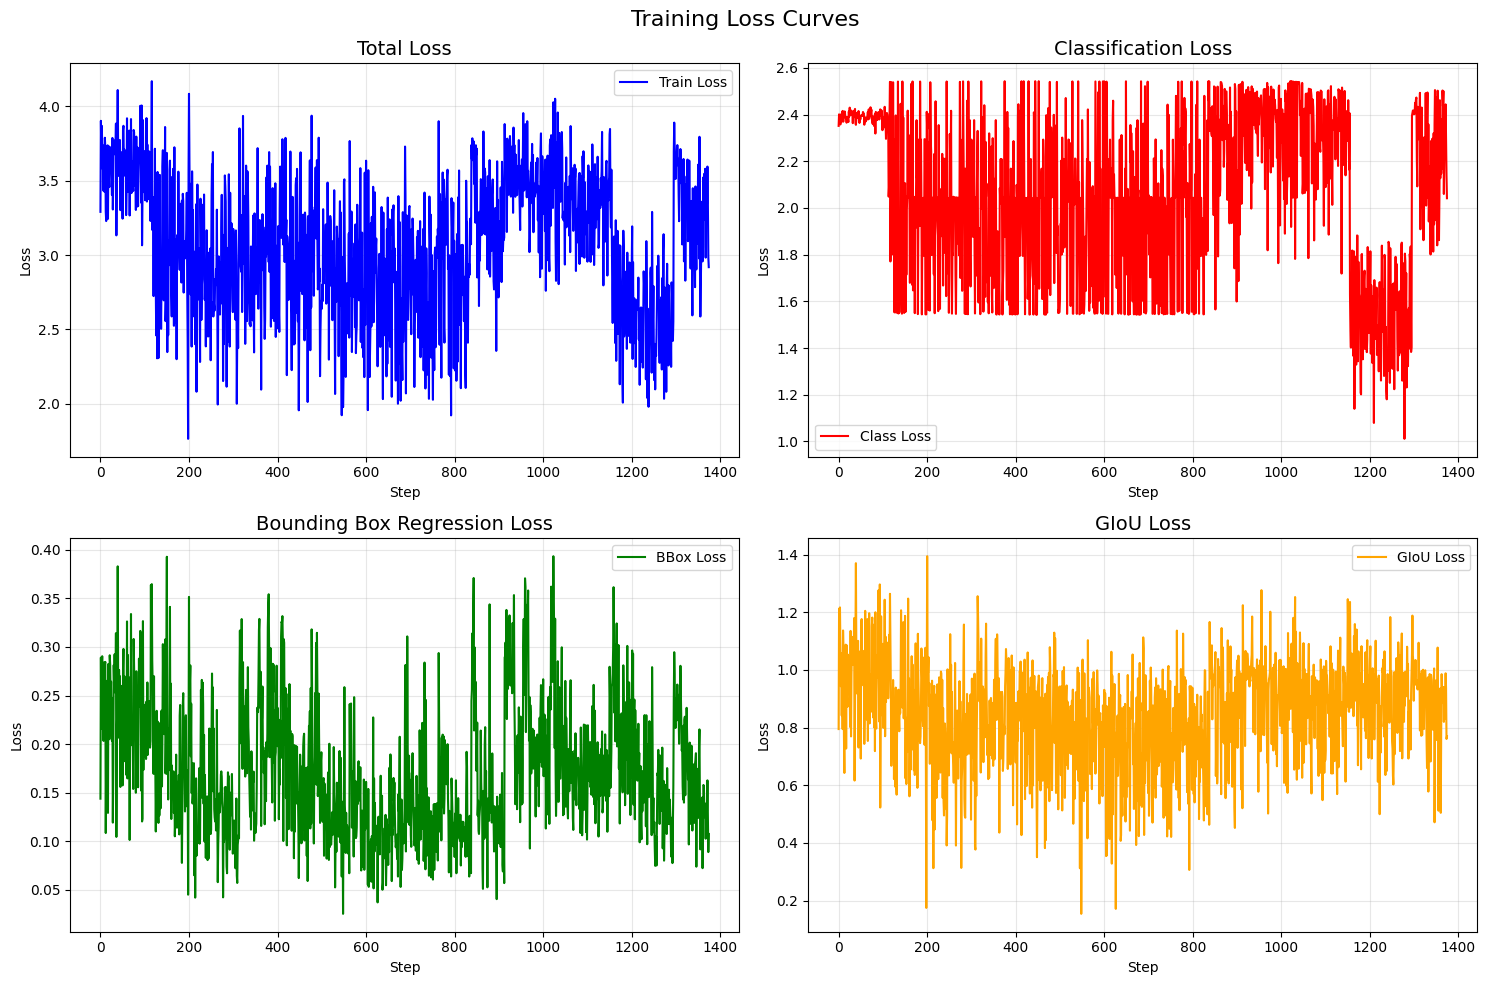

✅ Loss curves saved to ./analysis/loss_curves.png


In [16]:
# 4. Plot loss curves from TensorBoard
plot_loss_curves(config.log_dir, './analysis')

6. Провести **error analysis**: выделить ошибки классификации и локализации.

In [17]:
class_names = train_dataset.class_names
metrics = compute_map_and_metrics(model, val_loader, config.device, config.num_classes, class_names)

error_types = analyze_errors(model, val_loader, config.device, config.num_classes, class_names, num_samples=100)


📊 Computing mAP metrics...


Computing mAP: 100%|██████████| 50/50 [00:02<00:00, 20.23it/s]



📈 Per-class statistics:
Class           GT Count   Pred Count   Precision 
--------------------------------------------------
car             114        2226         19.526    
chair           67         696          10.388    
book            53         0            0.000     
bottle          64         313          4.891     
cup             45         0            0.000     
dining table    29         80           2.759     
bowl            68         0            0.000     
traffic light   35         0            0.000     
handbag         29         0            0.000     
bird            22         0            0.000     

🔍 Running error analysis...


Error Analysis: 100%|██████████| 50/50 [00:03<00:00, 15.89it/s]


📊 ERROR ANALYSIS SUMMARY

✅ Correct detections (IoU>0.5, correct class): 11
❌ Wrong class predictions: 18
📍 Poor localization (IoU<0.5): 458
🎯 False positives: 3246

📈 Average IoU for correct detections: 0.637
📊 Average confidence: 0.892


In [20]:
visualize_predictions(model, val_loader, config.device, class_names, save_dir='./analysis', num_images=10)


🎨 Generating visualizations to ./analysis...

Image 92053: 11 predictions with confidence >0.7
  Ground truth: 6 objects

Image 50149: 11 predictions with confidence >0.7
  Ground truth: 1 objects

Image 524456: 12 predictions with confidence >0.7
  Ground truth: 1 objects

Image 274411: 24 predictions with confidence >0.7
  Ground truth: 2 objects

Image 242060: 9 predictions with confidence >0.7
  Ground truth: 4 objects

Image 185802: 31 predictions with confidence >0.7
  Ground truth: 2 objects

Image 121417: 42 predictions with confidence >0.7
  Ground truth: 1 objects

Image 5037: 44 predictions with confidence >0.7
  Ground truth: 2 objects

Image 93437: 11 predictions with confidence >0.7
  Ground truth: 10 objects

Image 146155: 11 predictions with confidence >0.7
  Ground truth: 14 objects
✅ Saved 10 visualizations to ./analysis


In [21]:
print_metrics_table(metrics, error_types)


📊 FINAL METRICS TABLE

Metric                         Value           Description              
----------------------------------------------------------------------
mAP                            0.0000          Mean Average Precision   
mAP@0.5                        0.0000          mAP at IoU=0.5           
Total Predictions              3315            Number of detections     
Ground Truths                  526             Number of annotations    

Error Type                     Count           Percentage               
----------------------------------------------------------------------
Correct Detections             11              0.3                      %
Wrong Class                    18              0.5                      %
Poor Localization (IoU<0.5)    458             12.3                     %
False Positives                3246            87.0                     %


In [ ]:
with open('./analysis/summary_report.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("DETR TRAINING SUMMARY REPORT\n")
    f.write("="*60 + "\n\n")
    
    f.write(f"Device: {config.device}\n")
    f.write(f"Epochs: {config.epochs}\n")
    f.write(f"Batch Size: {config.batch_size}\n")
    f.write(f"Learning Rate: {config.lr}\n")
    f.write(f"Number of Classes: {config.num_classes}\n\n")
    
    f.write("Final Metrics:\n")
    f.write(f"  mAP: {metrics.get('mAP', 0.0):.4f}\n")
    f.write(f"  mAP@0.5: {metrics.get('mAP50', 0.0):.4f}\n")
    
    f.write("Error Analysis:\n")
    f.write(f"  Correct Detections: {len(error_types.get('correct', []))}\n")
    f.write(f"  Wrong Class: {len(error_types.get('wrong_class', []))}\n")
    f.write(f"  Poor Localization: {len(error_types.get('poor_localization', []))}\n")
    f.write(f"  False Positives: {len(error_types.get('false_positive', []))}\n")

print("\n📁 Analysis files saved to './analysis/'")
print("   - loss_curves.png")
print("   - prediction_*.png")
print("   - summary_report.txt")
print(f"   - Trace files in {config.trace_dir}/")

writer.close()
print("Analysis completed!")


📁 Analysis files saved to './analysis/'
   - loss_curves.png
   - prediction_*.png
   - summary_report.txt
   - Trace files in ./traces/
Analysis completed!
